[1033.33333333]
[1033.33333333]


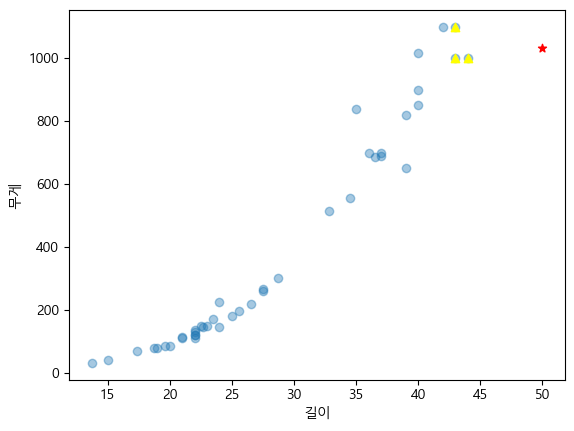

In [2]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
    train_test_split(perch_length, perch_weight, random_state=42)

train_input = train_input.reshape((-1,1))
test_input = test_input.reshape((-1, 1))

from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)
prediction = knr.predict([[50]])
print(prediction)

idx = knr.kneighbors([[50]], return_distance=False)

import matplotlib.pyplot as plt
plt.rc('font', family="Malgun Gothic")
plt.scatter(train_input, train_target, alpha=0.4)
plt.scatter(train_input[[idx]], train_target[[idx]], marker='^', c='yellow')
plt.scatter(50,  knr.predict([[50]]), marker='*', color='red')
plt.xlabel('길이', size=10)
plt.ylabel('무게', size=10)


print(knr.predict([[10000]]))

In [1]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_input, train_target)
lr.score(test_input, test_target)
lr.predict([[100]])

print(lr.coef_, lr.intercept_)
plt.rc('axes', unicode_minus = False)
plt.figure(dpi = 150)
plt.scatter(train_input, train_target, alpha=0.4)
plt.scatter(train_input[[idx]], train_target[[idx]], marker='^', c='yellow')
plt.scatter(50,  knr.predict([[50]]), marker='*', color='red')
plt.xlabel('길이', size=10)
plt.ylabel('무게', size=10)
plt.plot(train_input, lr.coef_*train_input + lr.intercept_)
plt.show()

print("훈련셋 스코어:",lr.score(train_input, train_target))
print("테스트셋 스코어:",lr.score(test_input, test_target) )

train_input

NameError: name 'train_input' is not defined

[  1.01433211 -21.55792498] 116.0502107827827
0.9706807451768623
0.9775935108325122


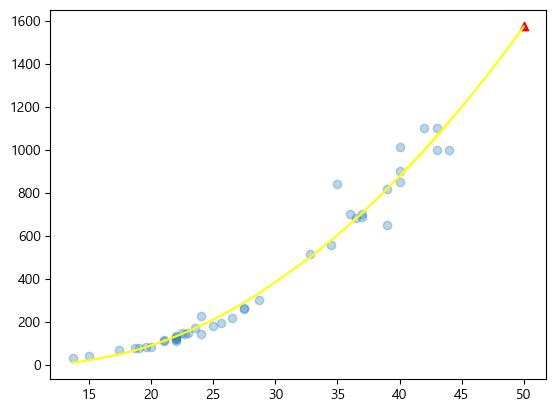

In [21]:
train_input2 = np.column_stack((train_input**2, train_input))
test_input2 = np.column_stack((test_input**2, test_input))

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_input2, train_target)
lr.predict([[50**2, 50]])
print(lr.coef_, lr.intercept_)

idx = np.argsort(train_input2[:, 1])
sort_x = train_input2[idx, 1]
sort_y = sort_x**2 * lr.coef_[0] + sort_x * lr.coef_[1] + lr.intercept_

point = np.arange(40, 51)

plt.scatter(train_input2[:, 1], train_target, alpha=0.3)
plt.plot(point, point**2 * lr.coef_[0] + point * lr.coef_[1] + lr.intercept_, color='yellow')
plt.plot(sort_x, sort_y, color='yellow')
plt.scatter(50, lr.predict([[50**2, 50]]), marker='^', color='red')

print(lr.score(train_input2, train_target))
print(lr.score(test_input2, test_target))